## COSIE-Foundation Tutorial

In this tutorial, we demonstrate how to use a pretrained COSIE-Foundation model to generate virtual pathology annotations for query section.

### Step 1 - Download COSIE-Foundation checkpoint

Download the pretrained COSIE-Foundation checkpoint from Hugging Face: [COSIE_Foundation_checkpoint.zip](https://huggingface.co/pennweili/cosie-foundation/tree/main). Then unzip the file and place it under: Inference/COSIE_Foundation_checkpoint/

In [1]:
!unzip COSIE_Foundation_checkpoint.zip -d Inference/

Archive:  COSIE_Foundation_checkpoint.zip
   creating: Inference/COSIE_Foundation_checkpoint/
  inflating: Inference/COSIE_Foundation_checkpoint/joint_embedding_PCA.joblib  
  inflating: Inference/COSIE_Foundation_checkpoint/joint_HE_PCA_model.joblib  
  inflating: Inference/COSIE_Foundation_checkpoint/cluster_centroid.npy  
  inflating: Inference/COSIE_Foundation_checkpoint/feature_dict_concat.pkl  
  inflating: Inference/COSIE_Foundation_checkpoint/adata_combined_HE.h5ad  
  inflating: Inference/COSIE_Foundation_checkpoint/cosie_trained.pt  


### Step 2 - Download example query data

Example adata_query.h5ad can be downloaded from [Here](https://upenn.app.box.com/folder/376926611542). 

After downloading, place the file in the current working directory.

### Step 3 - Run inference

In [2]:
import sys

!{sys.executable} Inference/1_label_transfer.py \
    --out-root Inference \
    --adata-path adata_query.h5ad

Using device: cpu
All required files found.

Step 1. Read query adata
Query n_obs = 538057

Step 2. Run HE PCA transform

Step 3. Build query AnnData for mapping

Step 4. Run Symphony/Harmony mapping

Step 5. Run COSIE inference
All modalities: ['HE', 'RNA', 'Protein']
-------- Encoder description --------
Encoder [HE]: Input 50 → Hidden [256, 128]
Encoder [RNA]: Input 50 → Hidden [256, 128]
Encoder [Protein]: Input 20 → Hidden [256, 128]
-------- Dual prediction module description --------
Predictor [HE → RNA]: [128, 512, 512, 128]
Predictor [RNA → HE]: [128, 512, 512, 128]
Predictor [HE → Protein]: [128, 512, 512, 128]
Predictor [Protein → HE]: [128, 512, 512, 128]
Predictor [RNA → Protein]: [128, 512, 512, 128]
Predictor [Protein → RNA]: [128, 512, 512, 128]
Processing section: s1

Step 6. Run embedding PCA + label transfer

Step 7. Save output AnnData
Saved metacell AnnData to: Inference/adata_query_metacell_inferred.h5ad

Step 8. Convert cluster labels to cell-type labels
Saved fi

### Output files

The following outputs will be saved in `Inference/`:

- **adata_query_inferred.h5ad**  
  Contains the inferred COSIE embeddings and virtual pathology annotations.

- **celltype_labels.png**  
  Visualization of the predicted pathology annotations at cellular resolution.

### Step 4 - Visualize virtual pathology annotations

Display the predicted pathology annotation generated by COSIE-Foundation.

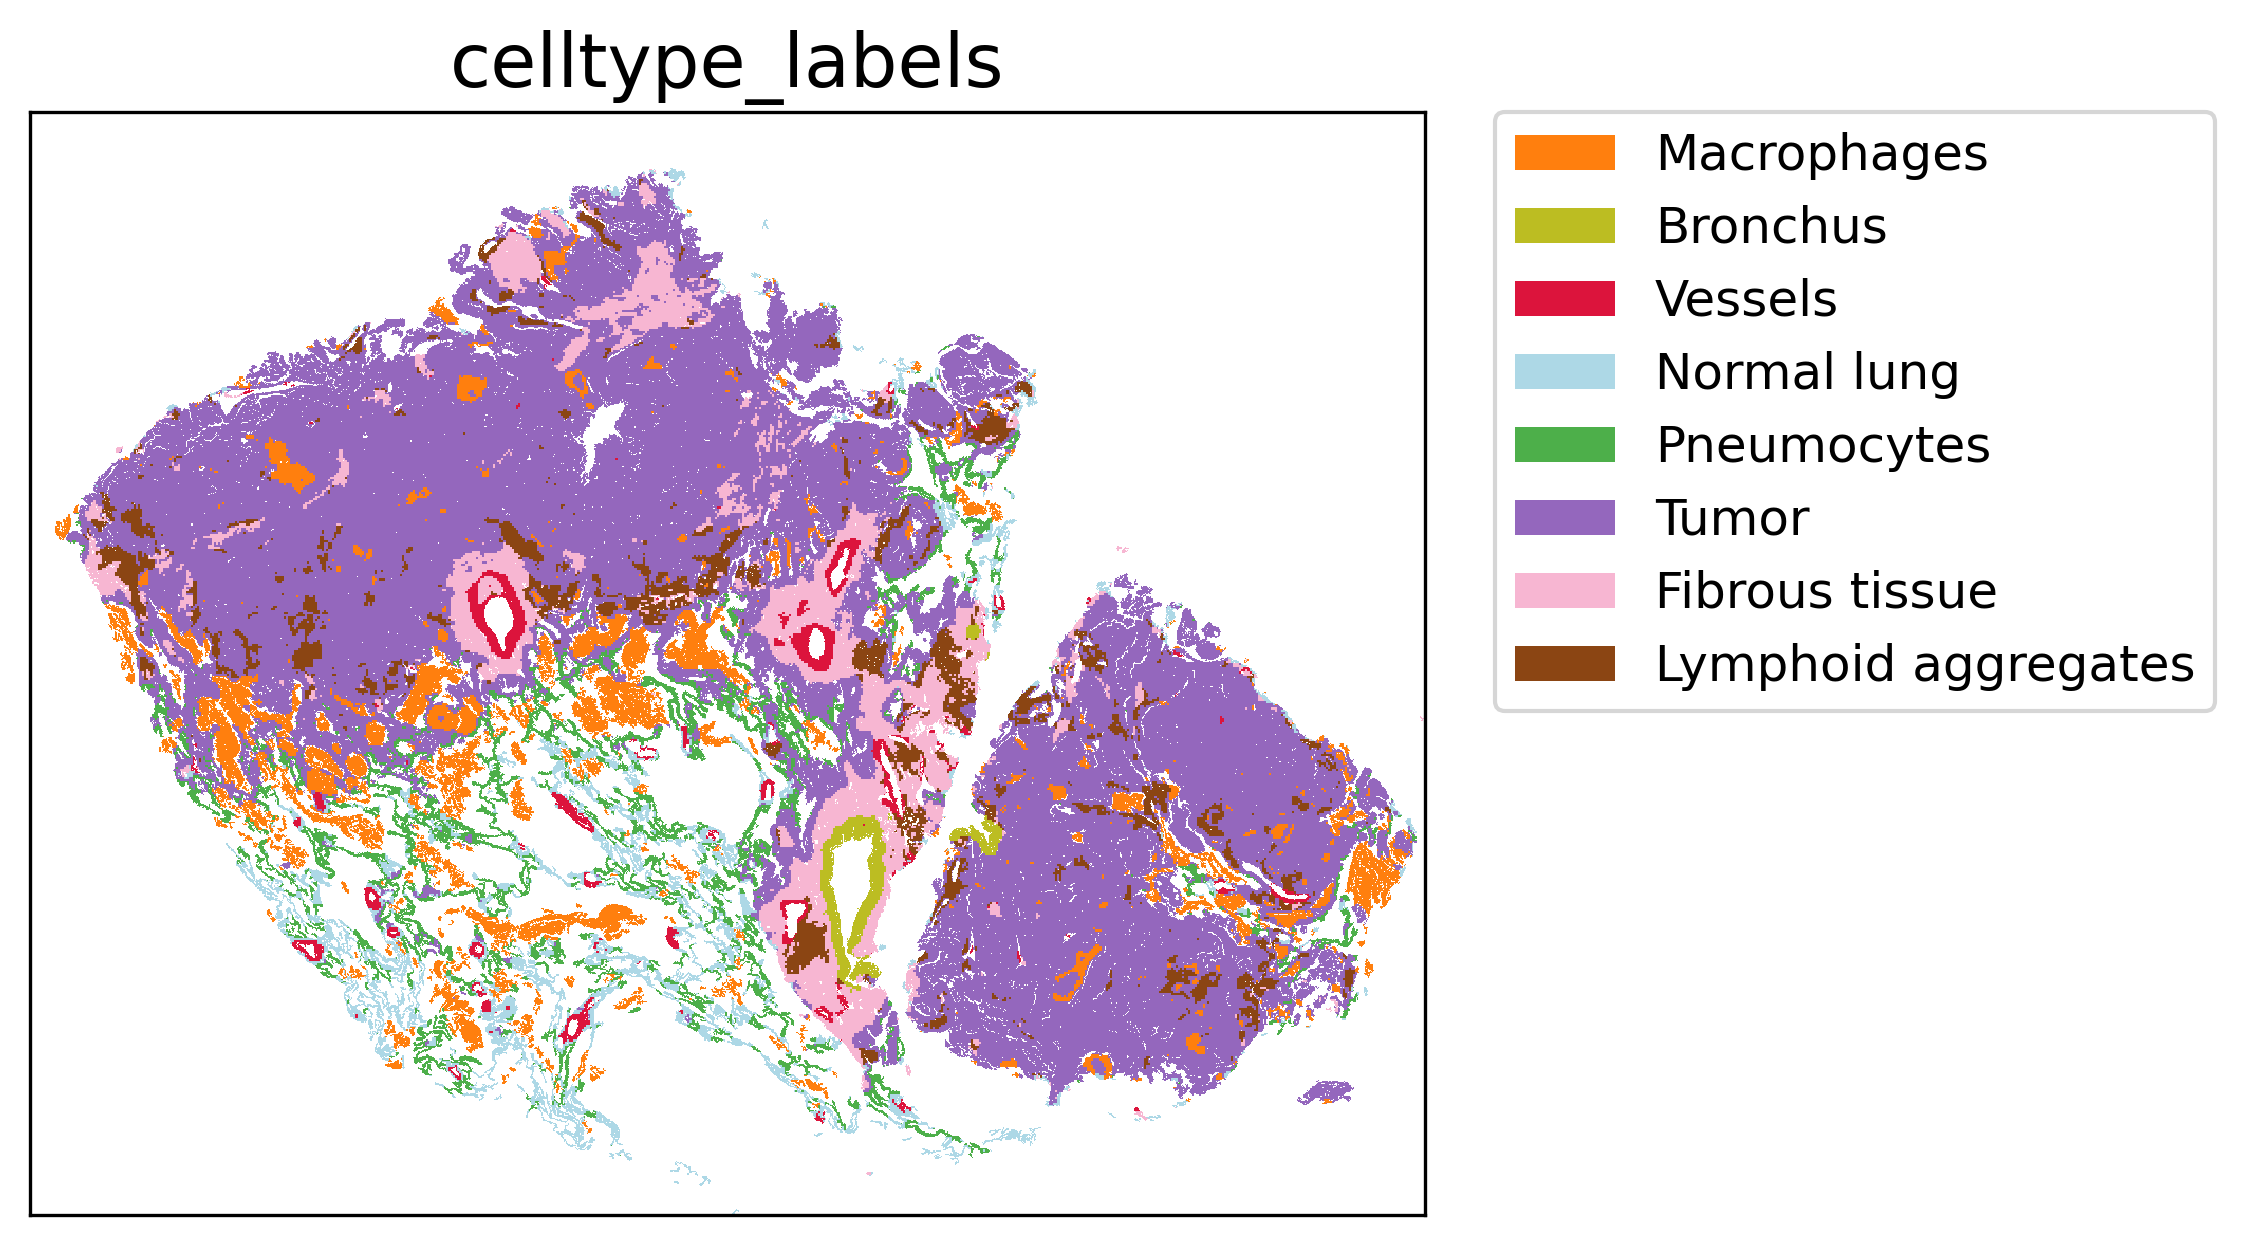

In [3]:
from IPython.display import Image, display
display(Image("Inference/celltype_labels.png"))